## Supernovae 1

Define the needed functions

In [14]:
import numpy as np
from astroML.datasets import generate_mu_z
from matplotlib import pyplot as plt
from astroML.linear_model import LinearRegression
from astroML.linear_model import PolynomialRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.model_selection import cross_val_predict
import pandas as pd

def geterror(y_true,y_pred):
    return np.sqrt( np.sum(( y_true - y_pred )**2) / len(y_true) )

def performFit(model,X,y,dy):
    m = model
    m.fit(X, y, dy)
    return m.predict(z_grid[:,np.newaxis]), m

def drawFit(label,ax = None,X=None,y=None, dy = None,errorbarlabel='Data'):
    if ax is None:
        fig, ax = plt.subplots()
    if X is None and y is None:
        X = z_sample
        y = mu_sample
        dy = dmu
    ax.errorbar(X, y, dy, fmt='.k', ecolor='gray', lw=1, alpha = 0.3,label=errorbarlabel)
    ax.plot(z_grid, mu_predict, label = label)
    ax.set_xlim(0.01, 1.8)
    ax.set_ylim(36.01, 48)
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(),loc='lower right')
    ax.set_ylabel(r'$\mu$')
    ax.set_xlabel(r'$z$')
    return ax

C:\Anaconda\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Load the data

(36.01, 48.0)

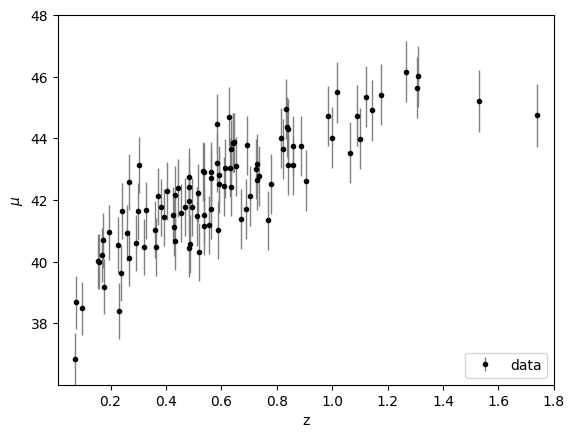

In [2]:
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) # YOU CANNOT CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0.01, 1.8)
plt.ylim(36.01, 48)

Perform a linear and polynomial fit regression

<Axes: xlabel='$z$', ylabel='$\\mu$'>

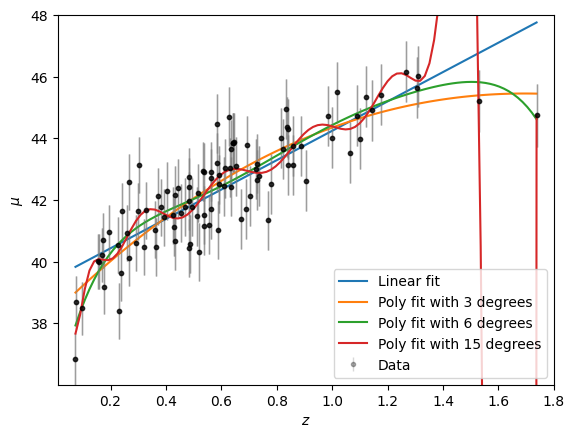

In [8]:
z_grid = np.linspace(z_sample.min(),z_sample.max(),100)
mu_predict, model = performFit(LinearRegression(),z_sample[:,np.newaxis],mu_sample,dmu)
fit_ax = drawFit('Linear fit')

n_degree = 3
mu_predict, model = performFit(PolynomialRegression(n_degree),z_sample[:,np.newaxis],mu_sample,dmu)
drawFit(f'Poly fit with {n_degree} degrees',fit_ax)

n_degree = 6
mu_predict, model = performFit(PolynomialRegression(n_degree),z_sample[:,np.newaxis],mu_sample,dmu)
drawFit(f'Poly fit with {n_degree} degrees',fit_ax)

n_degree = 15
mu_predict, model = performFit(PolynomialRegression(n_degree),z_sample[:,np.newaxis],mu_sample,dmu)
drawFit(f'Poly fit with {n_degree} degrees',fit_ax)

15 is definitely overfitting while linear is a underfit because it doesn't account for the low redshift values

Try with 2 and 4 which are reasonable

<Axes: xlabel='$z$', ylabel='$\\mu$'>

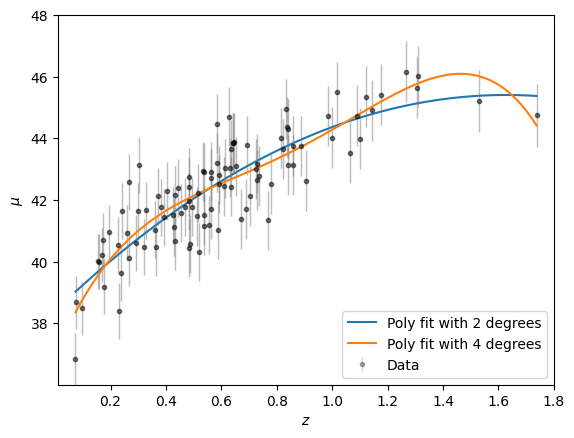

In [11]:
n_degree = 2
mu_predict, model = performFit(PolynomialRegression(n_degree),z_sample[:,np.newaxis],mu_sample,dmu)
fit_ax = drawFit(f'Poly fit with {n_degree} degrees',None)

n_degree = 4
mu_predict, model = performFit(PolynomialRegression(n_degree),z_sample[:,np.newaxis],mu_sample,dmu)
drawFit(f'Poly fit with {n_degree} degrees',fit_ax)

Perform the split of the data in training and validation

In [12]:
z_train, z_test, mu_train, mu_test, dmu_train, dmu_test = train_test_split(z_sample[:,np.newaxis], mu_sample, dmu, test_size=0.2, random_state=42)

Perform a GridSearch cross-validation with a custom scorer since the polynomialregression does not provide a score

In [15]:
degreerange = list(range(0, 11))
# squared = False to match the root mean square. greater_is_better=False because is a loss function.
# Note that GridSearchCV tries to maximize the score functionDefine RMSE scorer (negative for maximization in GridSearchCV)
# scorer = make_scorer(mean_squared_error, squared=False, greater_is_better=False)
# scorer = 'neg_mean_squared_error'
scorer = make_scorer(geterror, greater_is_better=False)
grid = GridSearchCV(PolynomialRegression(), {'degree': degreerange}, scoring=scorer, cv=5, return_train_score = True)
grid.fit(z_train, mu_train) # Drawback: I can't fit the errors
pd.DataFrame(grid.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_degree,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.000849,0.000433,0.000600,0.000490,0,{'degree': 0},-1.924133,-1.596839,-2.649231,-1.715397,...,-1.826975,0.465766,7,-1.827936,-1.908217,-1.600660,-1.885242,-1.967954,-1.838002,0.126871
1,0.000600,0.000490,0.000205,0.000410,1,{'degree': 1},-0.869075,-0.774848,-1.385251,-1.319192,...,-1.061021,0.245516,5,-1.045245,-1.063827,-0.914324,-0.956036,-1.024768,-1.000840,0.056576
2,0.000399,0.000489,0.000600,0.000490,2,{'degree': 2},-0.722485,-0.787994,-1.111172,-1.038361,...,-0.929262,0.148970,1,-0.936240,-0.922848,-0.856361,-0.866898,-0.873438,-0.891157,0.032094
3,0.000709,0.000400,0.000200,0.000399,3,{'degree': 3},-0.728985,-0.812183,-1.190951,-1.077222,...,-0.959223,0.169122,3,-0.935612,-0.920570,-0.849149,-0.864998,-0.873354,-0.888737,0.033401
4,0.001036,0.000075,0.000000,0.000000,4,{'degree': 4},-0.730502,-0.814919,-1.067064,-1.133902,...,-0.939272,0.150582,2,-0.900562,-0.884684,-0.831479,-0.845385,-0.846677,-0.861757,0.026244
5,0.000000,0.000000,0.000000,0.000000,5,{'degree': 5},-0.839212,-0.807671,-1.235237,-1.130759,...,-0.992789,0.165778,4,-0.881301,-0.884501,-0.827301,-0.845385,-0.841818,-0.856061,0.022759
6,0.000101,0.000202,0.000000,0.000000,6,{'degree': 6},-0.878712,-0.802113,-1.285470,-4.377618,...,-1.660054,1.368738,6,-0.874148,-0.883990,-0.824465,-0.835196,-0.838582,-0.851276,0.023375
7,0.001110,0.000199,0.000000,0.000000,7,{'degree': 7},-0.846936,-0.879914,-0.957609,-5.541311,...,-1.833851,1.854174,8,-0.858221,-0.843571,-0.823040,-0.826281,-0.815971,-0.833417,0.015371
8,0.000937,0.000153,0.000000,0.000000,8,{'degree': 8},-0.847104,-0.880088,-3.496531,-8.938200,...,-3.021110,3.126154,9,-0.858164,-0.843522,-0.816766,-0.824494,-0.815940,-0.831777,0.016513
9,0.000847,0.000436,0.000291,0.000382,9,{'degree': 9},-0.850912,-0.900719,-8.243169,-52.845630,...,-12.762246,20.242103,10,-0.857862,-0.841421,-0.806125,-0.821148,-0.811979,-0.827707,0.019254


Show the scores for the test and train set and the best degree

The best is {'degree': 2}


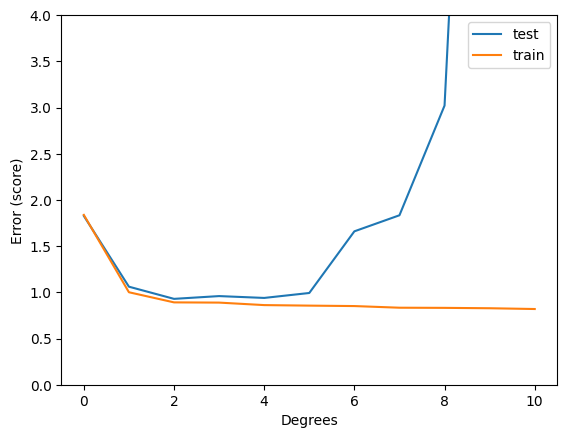

In [16]:
scores = (np.column_stack((-grid.cv_results_['mean_test_score'],-grid.cv_results_['mean_train_score'])))
fig, ax = plt.subplots()
ax.plot(degreerange,scores,label=['test','train'])
ax.set_ylim(0, 4)
ax.set_ylabel('Error (score)')
ax.set_xlabel('Degrees')
plt.legend()

print(f'The best is {grid.best_params_}')

At the beginning you are still improving the error and you're underfitting up to 2. Above 5 you're overfitting

Show the best fit, obtained only on training data. Show the trainining data and the prediction on the test data

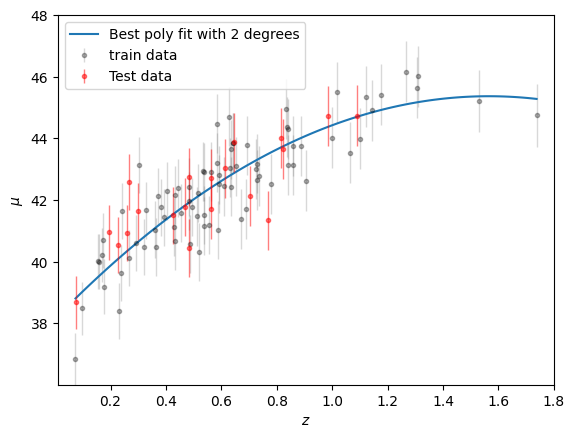

In [19]:
mu_predict = grid.best_estimator_.predict(z_grid[:,np.newaxis]) #fitted only on training data
best_fix_ax = drawFit(f'Best poly fit with {degreerange[grid.best_index_]} degrees',None,z_train,mu_train,dmu_train,'train data')
best_fix_ax.errorbar(z_test, mu_test, dmu_test, fmt='.r', ecolor='red', lw=1, alpha = 0.5, label = 'Test data')
best_fix_ax.legend()

An alternative for accounting for errors

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Pipeline
pipeline = Pipeline([
    ('poly', PolynomialFeatures()),
    ('linreg', LinearRegression())
])

param_grid = {
    'poly__degree': list(range(0, 11)),
    'linreg__fit_intercept': [True]
}

In [26]:
sample_weights = 1/(dmu_train**2)
grid = GridSearchCV(pipeline, param_grid, scoring=scorer, cv=5, return_train_score = True)
grid.fit(z_train, mu_train,linreg__sample_weight=sample_weights)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('poly', PolynomialFeatures()),
                                       ('linreg', LinearRegression())]),
             param_grid={'linreg__fit_intercept': [True],
                         'poly__degree': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]},
             return_train_score=True,
             scoring=make_scorer(geterror, greater_is_better=False))

The best is {'linreg__fit_intercept': True, 'poly__degree': 2}


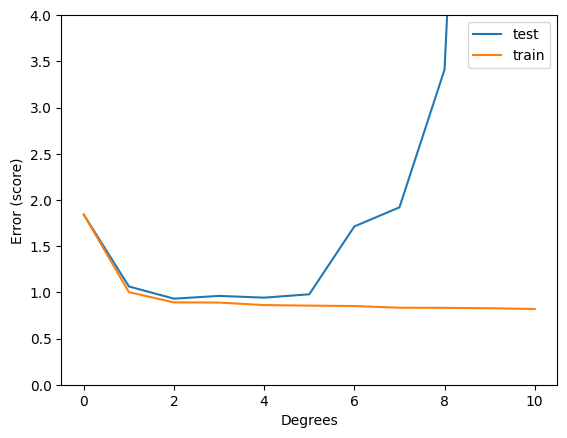

In [27]:
scores = (np.column_stack((-grid.cv_results_['mean_test_score'],-grid.cv_results_['mean_train_score'])))
fig, ax = plt.subplots()
ax.plot(degreerange,scores,label=['test','train'])
ax.set_ylim(0, 4)
ax.set_ylabel('Error (score)')
ax.set_xlabel('Degrees')
plt.legend()

print(f'The best is {grid.best_params_}')

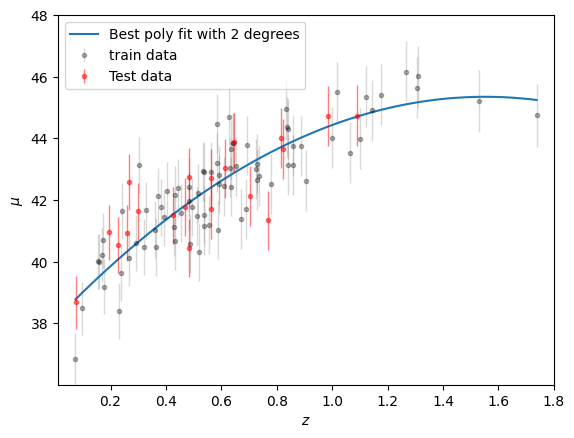

In [28]:
mu_predict = grid.best_estimator_.predict(z_grid[:,np.newaxis]) #fitted only on training data
best_fix_ax = drawFit(f'Best poly fit with {degreerange[grid.best_index_]} degrees',None,z_train,mu_train,dmu_train,'train data')
best_fix_ax.errorbar(z_test, mu_test, dmu_test, fmt='.r', ecolor='red', lw=1, alpha = 0.5, label = 'Test data')
best_fix_ax.legend()